In [23]:
import     pandas     as     pd
import os
from google.colab import drive

drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/SeminarioIAColab/')

# 1. Ler as duas planilhas do Excel
df1 = pd.read_excel('dados_1.xlsx')
df2 = pd.read_excel('dados_2.xlsx')

# 2. Juntar as duas lado a lado (mantendo a ordem     exata das linhas)
dados_completos = pd.concat([df1, df2], axis=1)

# 3. Mostre as primeiras linhas para confirmar se     deu certo
dados_completos.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_STATUS_REDACAO,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_REDACAO,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,SG_UF_PROVA,Q002,Q020
0,CE,2.0,1.0,60.0,60.0,80.0,300.0,210062064233,5,F,1,1,RS,F,B
1,SC,4.0,1.0,200.0,200.0,180.0,920.0,210062064234,11,F,1,1,RS,C,B
2,NaN,NaN,1.0,120.0,40.0,120.0,480.0,210062064235,11,F,1,1,RS,F,B
3,NaN,NaN,1.0,200.0,160.0,160.0,740.0,210062064236,3,F,3,2,RS,B,B
4,MA,2.0,NaN,NaN,NaN,NaN,NaN,210062064237,16,M,1,1,RS,B,B


In [24]:
# 1. Manter apenas candidatos com redação corrigida regularmente (Status = 1)
dados_limpos = dados_completos[dados_completos['TP_STATUS_REDACAO'] == 1].copy()

# 2. Filtrar para manter APENAS o estado de Minas Gerais (MG)
dados_limpos = dados_limpos[dados_limpos['SG_UF_ESC'] == 'MG']

# 3. Filtrar para garantir que não temos notas zeradas na redação
dados_limpos = dados_limpos[dados_limpos['NU_NOTA_REDACAO'] > 0]

# 4. Eliminar qualquer linha com dados em branco (valores nulos) em toda a base
dados_limpos = dados_limpos.dropna()

# 5. Mostrar o resultado final do corte
print(f"Quantidade de registros de MG após a limpeza: {dados_limpos.shape[0]}")
dados_limpos.head()

Quantidade de registros de MG após a limpeza: 24902


,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_STATUS_REDACAO,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_REDACAO,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,SG_UF_PROVA,Q002,Q020
67,MG,4.0,1.0,180.0,200.0,180.0,920.0,210062064418,6,F,3,1,BA,E,B
82,MG,2.0,1.0,200.0,160.0,180.0,920.0,210062064433,3,F,3,3,RS,E,B
101,MG,2.0,1.0,160.0,140.0,140.0,760.0,210062064502,17,F,3,1,RS,C,B
118,MG,2.0,1.0,140.0,120.0,120.0,540.0,210062064519,16,F,1,1,RS,D,B
134,MG,4.0,1.0,140.0,140.0,180.0,760.0,210062064538,11,M,1,1,SP,F,B


Quantidade de registros de MG após a limpeza: 24902

Base de dados totalmente numérica para o ANFIS:

In [25]:
# 1. Remover colunas de controle que não serão usadas no treinamento do ANFIS
colunas_para_remover = ['SG_UF_ESC', 'TP_STATUS_REDACAO']
dados_modelagem = dados_limpos.drop(columns=colunas_para_remover)

# 2. Identificar quais colunas ainda possuem textos (tipo 'object')
colunas_texto = dados_modelagem.select_dtypes(include=['object']).columns

# 3. Transformar os textos em números (0, 1, 2...) de forma automática
for col in colunas_texto:
    dados_modelagem[col] = dados_modelagem[col].astype('category').cat.codes

# 4. Mostrar o resultado final pronto para a Inteligência Artificial
print("Base de dados totalmente numérica para o ANFIS:")
dados_modelagem.head()

Base de dados totalmente numérica para o ANFIS:


,TP_DEPENDENCIA_ADM_ESC,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_REDACAO,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,SG_UF_PROVA,Q002,Q020
67,4.0,180.0,200.0,180.0,920.0,210062064418,6,0,3,1,4,4,1
82,2.0,200.0,160.0,180.0,920.0,210062064433,3,0,3,3,22,4,1
101,2.0,160.0,140.0,140.0,760.0,210062064502,17,0,3,1,22,2,1
118,2.0,140.0,120.0,120.0,540.0,210062064519,16,0,1,1,22,3,1
134,4.0,140.0,140.0,180.0,760.0,210062064538,11,1,1,1,25,5,1


In [26]:
!pip install scikit-fuzzy

import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)


#_____________ SAIDAS _____________

dados_modelagem_anfis = dados_modelagem.copy()

def classificar_nota_redacao(nota):
    if nota < 600:
        return 0  # baixa
    elif nota < 800:
        return 1  # média
    else:
        return 2  # alta

dados_modelagem_anfis['CLASSE_REDACAO'] = dados_modelagem_anfis['NU_NOTA_REDACAO'].apply(classificar_nota_redacao)

y_anfis = dados_modelagem_anfis['CLASSE_REDACAO'].values

nomes_classes = ['Baixa', 'Média', 'Alta']
num_classes = 3

print("="*60)
print("Distribuição das classes na base completa:")
print(pd.Series(y_anfis).value_counts().sort_index())
print("="*60)


#_______________ ENTRADAS  _______________

X_anfis = dados_modelagem_anfis.drop(columns=['NU_NOTA_REDACAO', 'CLASSE_REDACAO'])

colunas_limpas = []

for col in X_anfis.columns:
    col_upper = col.upper()

    if "NOTA" in col_upper or "INSCRICAO" in col_upper or "ID" in col_upper or "COMP" in col_upper:
        continue

    colunas_limpas.append(col)

X_anfis_filtrado = X_anfis[colunas_limpas].copy()

# SELEÇÃO MANUAL: Tipo de Escola, Escolaridade da Mãe (Q002) e Internet (Q020)
melhores_colunas = ['TP_DEPENDENCIA_ADM_ESC', 'Q002', 'Q020']

X_anfis_otimizado = X_anfis_filtrado[melhores_colunas].values.astype(float)


#_______________ TESTE VS TREINO _______________

total_amostras = len(X_anfis_otimizado)

contagem_classes = pd.Series(y_anfis).value_counts()

if contagem_classes.min() >= 2:
    estratificacao = y_anfis
else:
    estratificacao = None
    print("Atenção: alguma classe possui menos de 2 amostras. A separação será feita sem stratify.")

X_treino_base, X_teste, y_treino_base, y_teste = train_test_split(
    X_anfis_otimizado,
    y_anfis,
    test_size=0.20,
    random_state=42,
    stratify=estratificacao
)

print("="*60)
print(f"Número Total de Alunos: {total_amostras}")
print(f"Amostras para Treinamento (80%): {len(X_treino_base)}")
print(f"Amostras para Teste (20%): {len(X_teste)}")
print(f"Variáveis de entrada selecionadas: {melhores_colunas}")
print("="*60)

print("\nDistribuição das classes no treinamento original:")
print(pd.Series(y_treino_base).value_counts().sort_index())

print("\nDistribuição das classes no teste:")
print(pd.Series(y_teste).value_counts().sort_index())
print("="*60)


#_______________ FUNÇÕES AUXILIARES DO ANFIS _______________

def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)


def inicializar_parametros_anfis(X_treino, y_treino):
    parametros_iniciais = []

    for j in range(len(melhores_colunas)):
        col_data = X_treino[:, j]

        c1 = np.percentile(col_data, 20)
        c2 = np.percentile(col_data, 50)
        c3 = np.percentile(col_data, 80)

        sigma = np.std(col_data) if np.std(col_data) > 0 else 1.0

        parametros_iniciais.extend([
            c1, sigma,
            c2, sigma,
            c3, sigma
        ])

    # Consequentes iniciais para classificação
    pesos_consequentes_iniciais = np.array([
        [2.0, 0.0, 0.0],  # regra baixa favorece classe baixa
        [0.0, 2.0, 0.0],  # regra média favorece classe média
        [0.0, 0.0, 2.0]   # regra alta favorece classe alta
    ])

    # Bias inicial baseado na distribuição das classes do treino usado no modelo
    contagem_treino = np.bincount(y_treino, minlength=num_classes)

    bias_inicial = np.log(
        (contagem_treino + 1) / np.sum(contagem_treino + 1)
    )

    params_totais_iniciais = np.concatenate([
        np.array(parametros_iniciais, dtype=float),
        pesos_consequentes_iniciais.flatten(),
        bias_inicial
    ])

    return params_totais_iniciais


def forward_anfis(params, X):
    num_alunos = X.shape[0]

    qtd_params_fuzzy = len(melhores_colunas) * 6

    p_fuzzy = params[:qtd_params_fuzzy]

    inicio_consequentes = qtd_params_fuzzy
    fim_consequentes = inicio_consequentes + (3 * num_classes)

    p_consequente = params[inicio_consequentes:fim_consequentes].reshape(3, num_classes)

    bias = params[fim_consequentes:fim_consequentes + num_classes]

    probabilidades = np.zeros((num_alunos, num_classes))

    for i in range(num_alunos):
        graus_regra = []

        for j in range(len(melhores_colunas)):
            val = X[i, j]
            idx = j * 6

            c1 = p_fuzzy[idx]
            s1 = max(abs(p_fuzzy[idx + 1]), 1e-3)

            c2 = p_fuzzy[idx + 2]
            s2 = max(abs(p_fuzzy[idx + 3]), 1e-3)

            c3 = p_fuzzy[idx + 4]
            s3 = max(abs(p_fuzzy[idx + 5]), 1e-3)

            mu1 = fuzz.gaussmf(val, c1, s1)
            mu2 = fuzz.gaussmf(val, c2, s2)
            mu3 = fuzz.gaussmf(val, c3, s3)

            graus_regra.append([mu1, mu2, mu3])

        forca_baixa = np.prod([graus_regra[j][0] for j in range(len(melhores_colunas))])
        forca_media = np.prod([graus_regra[j][1] for j in range(len(melhores_colunas))])
        forca_alta = np.prod([graus_regra[j][2] for j in range(len(melhores_colunas))])

        forcas = np.array([forca_baixa, forca_media, forca_alta])
        soma_forcas = np.sum(forcas)

        if soma_forcas > 0:
            forcas_normalizadas = forcas / soma_forcas
        else:
            forcas_normalizadas = np.array([1/3, 1/3, 1/3])

        logits = np.dot(forcas_normalizadas, p_consequente) + bias

        probabilidades[i] = softmax(logits)

    return probabilidades


def prever_classes_anfis(params, X):
    probabilidades = forward_anfis(params, X)
    classes_preditas = np.argmax(probabilidades, axis=1)

    return classes_preditas


def funcao_custo_anfis(params, X, y):
    probabilidades = forward_anfis(params, X)

    probabilidades = np.clip(probabilidades, 1e-9, 1 - 1e-9)

    return log_loss(
        y,
        probabilidades,
        labels=np.arange(num_classes)
    )


def avaliar_modelo(nome_modelo, parametros_otimizados, X_teste, y_teste):
    probabilidades_preditas = forward_anfis(parametros_otimizados, X_teste)
    classes_preditas = prever_classes_anfis(parametros_otimizados, X_teste)

    acc = accuracy_score(y_teste, classes_preditas)

    precision_macro = precision_score(
        y_teste,
        classes_preditas,
        average='macro',
        zero_division=0
    )

    recall_macro = recall_score(
        y_teste,
        classes_preditas,
        average='macro',
        zero_division=0
    )

    f1_macro = f1_score(
        y_teste,
        classes_preditas,
        average='macro',
        zero_division=0
    )

    loss_teste = log_loss(
        y_teste,
        np.clip(probabilidades_preditas, 1e-9, 1 - 1e-9),
        labels=np.arange(num_classes)
    )

    print("\n" + "="*60)
    print(f"RESULTADO DO DESEMPENHO — {nome_modelo}")
    print("="*60)
    print(f"Acurácia:        {acc:.4f}")
    print(f"Precision macro: {precision_macro:.4f}")
    print(f"Recall macro:    {recall_macro:.4f}")
    print(f"F1-score macro:  {f1_macro:.4f}")
    print(f"Log Loss:        {loss_teste:.4f}")
    print("="*60)

    print("\nRelatório de classificação:")
    print(classification_report(
        y_teste,
        classes_preditas,
        labels=np.arange(num_classes),
        target_names=nomes_classes,
        zero_division=0
    ))

    matriz_confusao = confusion_matrix(
        y_teste,
        classes_preditas,
        labels=np.arange(num_classes)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz_confusao,
        display_labels=nomes_classes
    )

    disp.plot()
    plt.title(f"Matriz de Confusão — {nome_modelo}")
    plt.show()

    resultado = {
        'modelo': nome_modelo,
        'acuracia': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'log_loss': loss_teste
    }

    return resultado


def plotar_funcoes_pertinencia(parametros_otimizados, nome_modelo):
    qtd_params_fuzzy = len(melhores_colunas) * 6
    p_fuzzy_otimizados = parametros_otimizados[:qtd_params_fuzzy]

    for j, coluna in enumerate(melhores_colunas):
        idx = j * 6

        c1 = p_fuzzy_otimizados[idx]
        s1 = max(abs(p_fuzzy_otimizados[idx + 1]), 1e-3)

        c2 = p_fuzzy_otimizados[idx + 2]
        s2 = max(abs(p_fuzzy_otimizados[idx + 3]), 1e-3)

        c3 = p_fuzzy_otimizados[idx + 4]
        s3 = max(abs(p_fuzzy_otimizados[idx + 5]), 1e-3)

        x_min = X_anfis_otimizado[:, j].min()
        x_max = X_anfis_otimizado[:, j].max()

        if x_min == x_max:
            x_min -= 1
            x_max += 1

        x_plot = np.linspace(x_min, x_max, 300)

        plt.figure(figsize=(8, 4))

        plt.plot(x_plot, fuzz.gaussmf(x_plot, c1, s1), label='Baixa')
        plt.plot(x_plot, fuzz.gaussmf(x_plot, c2, s2), label='Média')
        plt.plot(x_plot, fuzz.gaussmf(x_plot, c3, s3), label='Alta')

        plt.ylabel('Grau de Pertinência')
        plt.xlabel(coluna)
        plt.title(f'Funções de Pertinência Otimizadas — {coluna} — {nome_modelo}')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()


def treinar_anfis(nome_modelo, X_treino_modelo, y_treino_modelo, X_teste, y_teste, maxiter=120, plotar_pertinencia=True):
    print("\n" + "="*60)
    print(f"INÍCIO DO TREINAMENTO — {nome_modelo}")
    print("="*60)

    print("\nDistribuição das classes no treino usado neste modelo:")
    print(pd.Series(y_treino_modelo).value_counts().sort_index())

    params_totais_iniciais = inicializar_parametros_anfis(
        X_treino_modelo,
        y_treino_modelo
    )

    classes_preditas_iniciais = prever_classes_anfis(
        params_totais_iniciais,
        X_teste
    )

    acc_inicial = accuracy_score(y_teste, classes_preditas_iniciais)

    f1_inicial = f1_score(
        y_teste,
        classes_preditas_iniciais,
        average='macro',
        zero_division=0
    )

    print("\nDesempenho antes do treinamento:")
    print(f"Acurácia inicial:       {acc_inicial:.4f}")
    print(f"F1-score macro inicial: {f1_inicial:.4f}")

    resultado_treino = minimize(
        funcao_custo_anfis,
        params_totais_iniciais,
        args=(X_treino_modelo, y_treino_modelo),
        method='Nelder-Mead',
        options={'maxiter': maxiter}
    )

    parametros_otimizados = resultado_treino.x

    print("\n" + "="*60)
    print(f"PARAMETROS OTIMIZADOS — {nome_modelo}")
    print("="*60)
    print("Quantidade de parametros:", len(parametros_otimizados))
    print(parametros_otimizados)
    print("="*60)

    resultado = avaliar_modelo(
        nome_modelo,
        parametros_otimizados,
        X_teste,
        y_teste
    )

    resultado['acuracia_inicial'] = acc_inicial
    resultado['f1_macro_inicial'] = f1_inicial

    if plotar_pertinencia:
        plotar_funcoes_pertinencia(parametros_otimizados, nome_modelo)

    return parametros_otimizados, resultado

Distribuição das classes na base completa:
0    7053
1    9785
2    8064
Name: count, dtype: int64
Número Total de Alunos: 24902
Amostras para Treinamento (80%): 19921
Amostras para Teste (20%): 4981
Variáveis de entrada selecionadas: ['TP_DEPENDENCIA_ADM_ESC', 'Q002', 'Q020']

Distribuição das classes no treinamento original:
0    5642
1    7828
2    6451
Name: count, dtype: int64

Distribuição das classes no teste:
0    1411
1    1957
2    1613
Name: count, dtype: int64



INÍCIO DO TREINAMENTO — Modelo 0 — ANFIS sem Balanceamento

Distribuição das classes no treino usado neste modelo:
0    5642
1    7828
2    6451
Name: count, dtype: int64

Desempenho antes do treinamento:
Acurácia inicial:       0.4614
F1-score macro inicial: 0.4376

PARAMETROS OTIMIZADOS — Modelo 0 — ANFIS sem Balanceamento
Quantidade de parametros: 30
[ 2.00375993e+00  8.58616555e-01  2.06730096e+00  7.91345035e-01
  3.88546022e+00  8.90511490e-01  2.30528547e+00  1.76794199e+00
  3.41565214e+00  1.71012888e+00  4.91556407e+00  1.88886779e+00
  1.01867883e+00  3.35313202e-01  1.00727173e+00  3.40728772e-01
  1.07280881e+00  3.46938878e-01  1.94083307e+00  2.74815385e-06
 -4.86813203e-07  5.24482355e-05  1.51943333e+00  1.91633571e-05
  5.80108432e-06 -1.75359926e-05  2.02263214e+00 -1.25120123e+00
 -9.69789915e-01 -1.12908274e+00]

RESULTADO DO DESEMPENHO — Modelo 0 — ANFIS sem Balanceamento
Acurácia:        0.4638
Precision macro: 0.4780
Recall macro:    0.4391
F1-score macro:  0.4

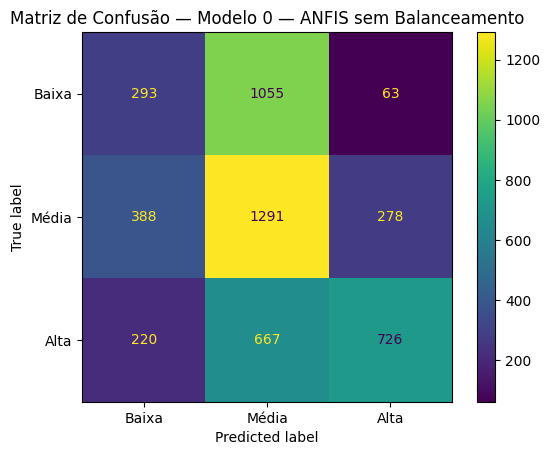

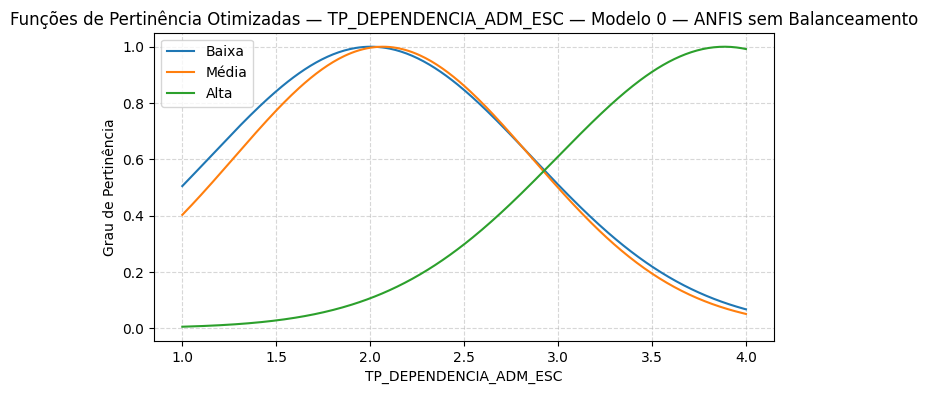

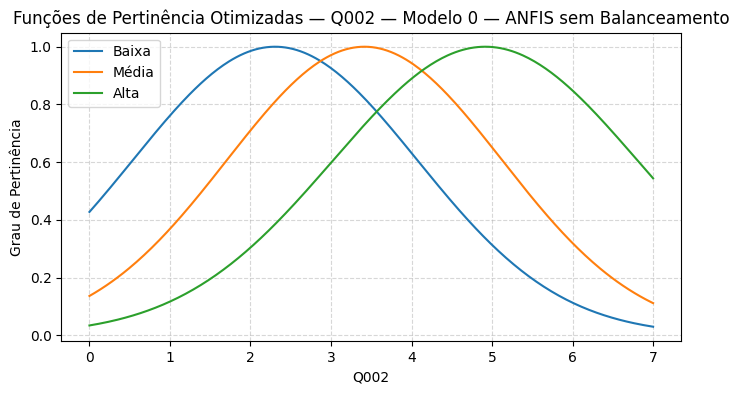

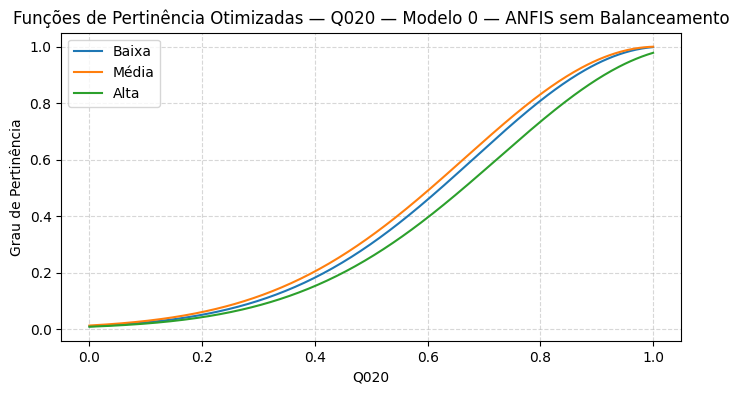

In [27]:
# ============================================================
# MODELO 0 — ANFIS CLASSIFICADOR SEM BALANCEAMENTO
# ============================================================

parametros_modelo0, resultado_modelo0 = treinar_anfis(
    nome_modelo='Modelo 0 — ANFIS sem Balanceamento',
    X_treino_modelo=X_treino_base,
    y_treino_modelo=y_treino_base,
    X_teste=X_teste,
    y_teste=y_teste,
    maxiter=120,
    plotar_pertinencia=True
)


BALANCEAMENTO — RANDOM OVERSAMPLING

Distribuição das classes antes do balanceamento:
0    5642
1    7828
2    6451
Name: count, dtype: int64

Distribuição das classes após Random OverSampling:
0    7828
1    7828
2    7828
Name: count, dtype: int64

Distribuição das classes no teste, sem balanceamento:
0    1411
1    1957
2    1613
Name: count, dtype: int64

INÍCIO DO TREINAMENTO — Modelo 1 — ANFIS com Random OverSampling

Distribuição das classes no treino usado neste modelo:
0    7828
1    7828
2    7828
Name: count, dtype: int64

Desempenho antes do treinamento:
Acurácia inicial:       0.4377
F1-score macro inicial: 0.4361

PARAMETROS OTIMIZADOS — Modelo 1 — ANFIS com Random OverSampling
Quantidade de parametros: 30
[ 1.95631282e+00  8.45789530e-01  2.05005619e+00  9.02497333e-01
  3.85391381e+00  9.19145345e-01  2.13734238e+00  1.81916405e+00
  3.64251878e+00  1.88096898e+00  5.02377430e+00  1.78236572e+00
  1.01638864e+00  3.31663317e-01  9.97516427e-01  3.37339759e-01
  1.06730

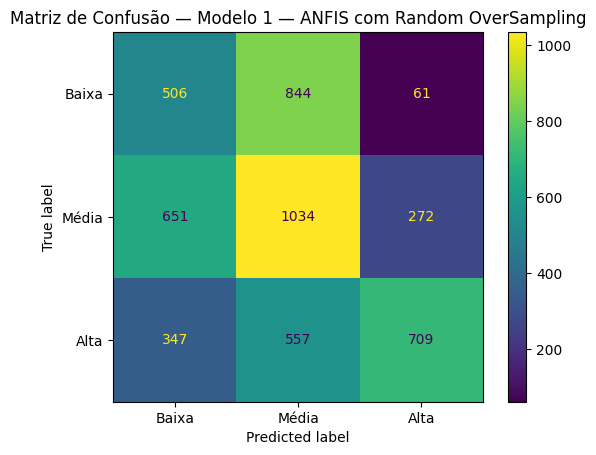

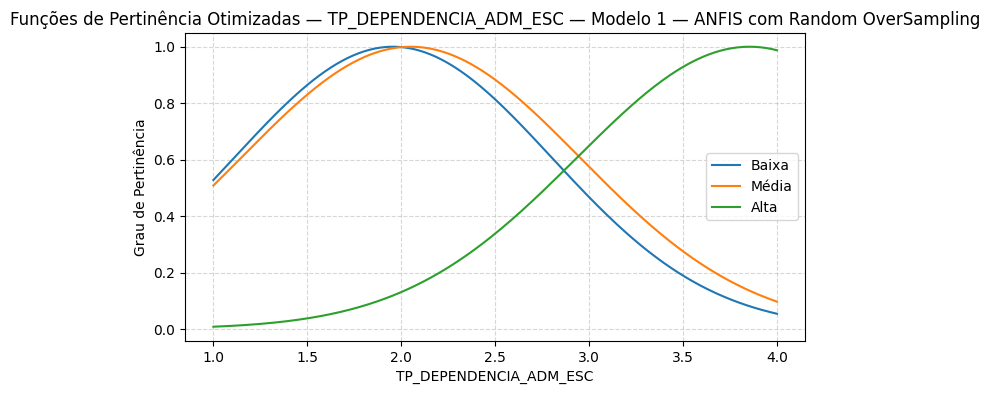

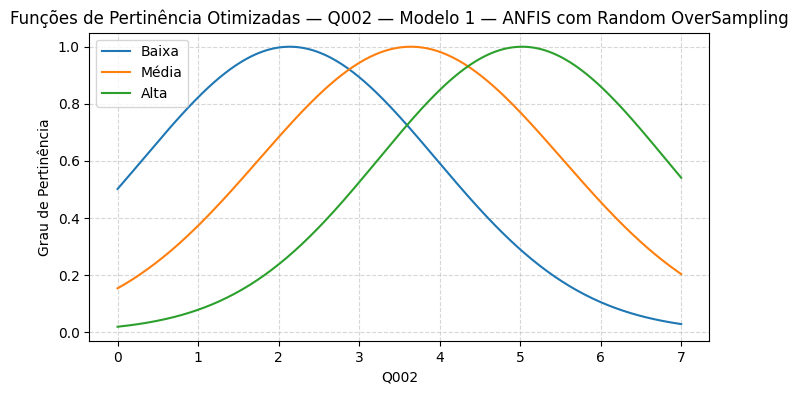

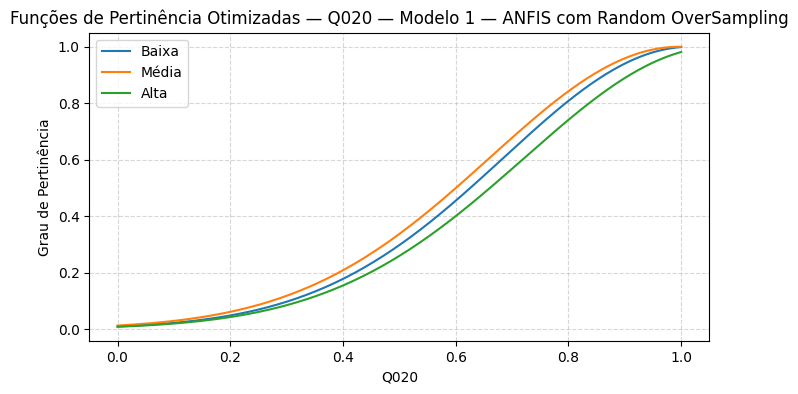

In [28]:

# ============================================================
# MODELO 1 — ANFIS CLASSIFICADOR COM RANDOM OVERSAMPLING
# ============================================================

from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=42)

X_treino_over, y_treino_over = oversampler.fit_resample(
    X_treino_base,
    y_treino_base
)

print("\n" + "="*60)
print("BALANCEAMENTO — RANDOM OVERSAMPLING")
print("="*60)

print("\nDistribuição das classes antes do balanceamento:")
print(pd.Series(y_treino_base).value_counts().sort_index())

print("\nDistribuição das classes após Random OverSampling:")
print(pd.Series(y_treino_over).value_counts().sort_index())

print("\nDistribuição das classes no teste, sem balanceamento:")
print(pd.Series(y_teste).value_counts().sort_index())
print("="*60)

parametros_modelo1, resultado_modelo1 = treinar_anfis(
    nome_modelo='Modelo 1 — ANFIS com Random OverSampling',
    X_treino_modelo=X_treino_over,
    y_treino_modelo=y_treino_over,
    X_teste=X_teste,
    y_teste=y_teste,
    maxiter=120,
    plotar_pertinencia=True
)


BALANCEAMENTO — SMOTEN

Distribuição das classes antes do balanceamento:
0    5642
1    7828
2    6451
Name: count, dtype: int64

Distribuição das classes após SMOTEN:
0    7828
1    7828
2    7828
Name: count, dtype: int64

Distribuição das classes no teste, sem balanceamento:
0    1411
1    1957
2    1613
Name: count, dtype: int64

INÍCIO DO TREINAMENTO — Modelo 2 — ANFIS com SMOTEN

Distribuição das classes no treino usado neste modelo:
0    7828
1    7828
2    7828
Name: count, dtype: int64

Desempenho antes do treinamento:
Acurácia inicial:       0.4377
F1-score macro inicial: 0.4361

PARAMETROS OTIMIZADOS — Modelo 2 — ANFIS com SMOTEN
Quantidade de parametros: 30
[ 1.98645148e+00  8.54581378e-01  1.99543388e+00  9.16238009e-01
  4.14078854e+00  9.31276684e-01  2.15811249e+00  1.81818273e+00
  3.68073915e+00  1.76868560e+00  4.79892663e+00  1.79734322e+00
  1.01540710e+00  3.37360354e-01  9.85439717e-01  3.41500959e-01
  1.00179158e+00  3.50102442e-01  1.95550639e+00  1.63891027e

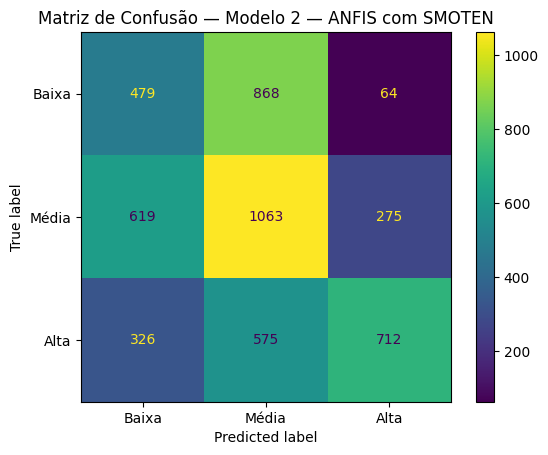

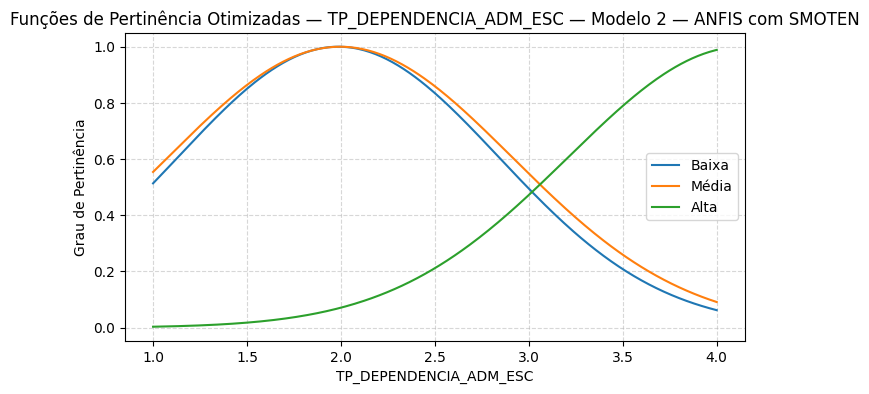

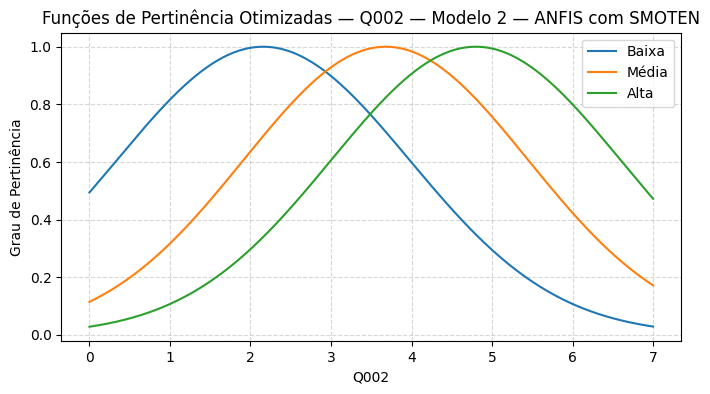

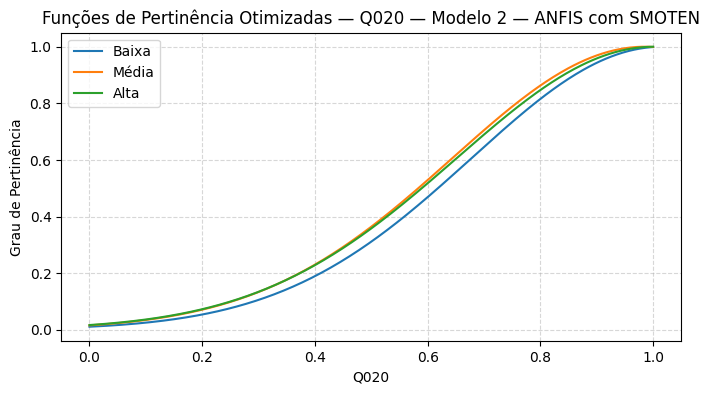

In [29]:
# ============================================================
# MODELO 2 — ANFIS CLASSIFICADOR COM SMOTEN
# ============================================================

from imblearn.over_sampling import SMOTEN
from imblearn.under_sampling import RandomUnderSampler


# O SMOTEN é indicado para variáveis categóricas.
# Como as variáveis foram codificadas numericamente, usamos int no balanceamento.
X_treino_smot_input = X_treino_base.astype(int)

smoten = SMOTEN(random_state=42, k_neighbors=5)

X_treino_smoten, y_treino_smoten = smoten.fit_resample(
    X_treino_smot_input,
    y_treino_base
)

# Converte novamente para float para manter compatibilidade com o ANFIS
X_treino_smoten = X_treino_smoten.astype(float)

print("\n" + "="*60)
print("BALANCEAMENTO — SMOTEN")
print("="*60)

print("\nDistribuição das classes antes do balanceamento:")
print(pd.Series(y_treino_base).value_counts().sort_index())

print("\nDistribuição das classes após SMOTEN:")
print(pd.Series(y_treino_smoten).value_counts().sort_index())

print("\nDistribuição das classes no teste, sem balanceamento:")
print(pd.Series(y_teste).value_counts().sort_index())
print("="*60)

parametros_modelo2, resultado_modelo2 = treinar_anfis(
    nome_modelo='Modelo 2 — ANFIS com SMOTEN',
    X_treino_modelo=X_treino_smoten,
    y_treino_modelo=y_treino_smoten,
    X_teste=X_teste,
    y_teste=y_teste,
    maxiter=120,
    plotar_pertinencia=True
)


BALANCEAMENTO — RANDOM UNDERSAMPLING

Distribuição das classes antes do balanceamento:
0    5642
1    7828
2    6451
Name: count, dtype: int64

Distribuição das classes após Random UnderSampling:
0    5642
1    5642
2    5642
Name: count, dtype: int64

Distribuição das classes no teste, sem balanceamento:
0    1411
1    1957
2    1613
Name: count, dtype: int64

INÍCIO DO TREINAMENTO — Modelo 3 — ANFIS com Random UnderSampling

Distribuição das classes no treino usado neste modelo:
0    5642
1    5642
2    5642
Name: count, dtype: int64

Desempenho antes do treinamento:
Acurácia inicial:       0.4377
F1-score macro inicial: 0.4361

PARAMETROS OTIMIZADOS — Modelo 3 — ANFIS com Random UnderSampling
Quantidade de parametros: 30
[ 1.98874772e+00  8.64303863e-01  1.74956390e+00  9.29540445e-01
  3.87853954e+00  8.83672223e-01  2.14801173e+00  1.81632332e+00
  3.62947223e+00  1.91534901e+00  4.80089058e+00  1.74991527e+00
  1.03551814e+00  3.39394320e-01  1.01498132e+00  3.38566079e-01
  1.0

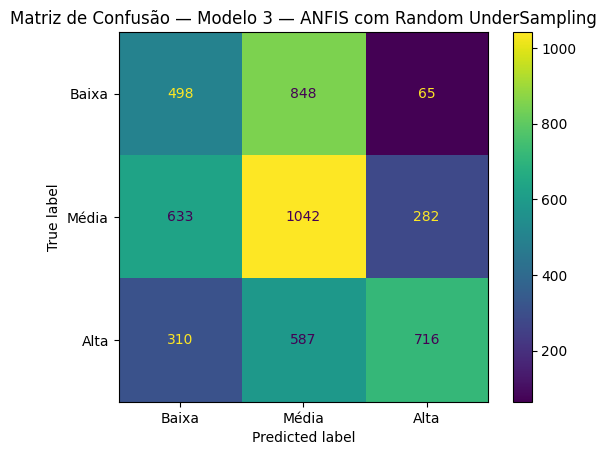

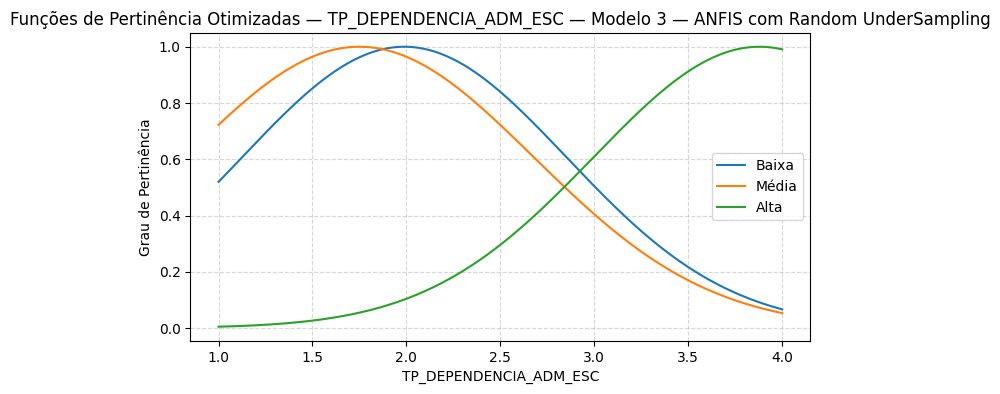

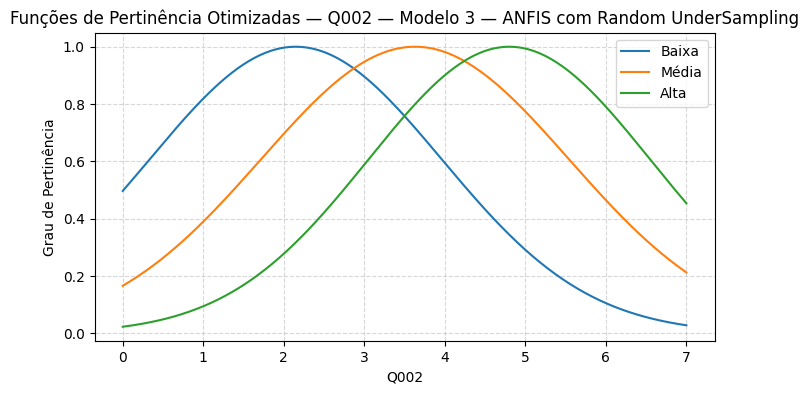

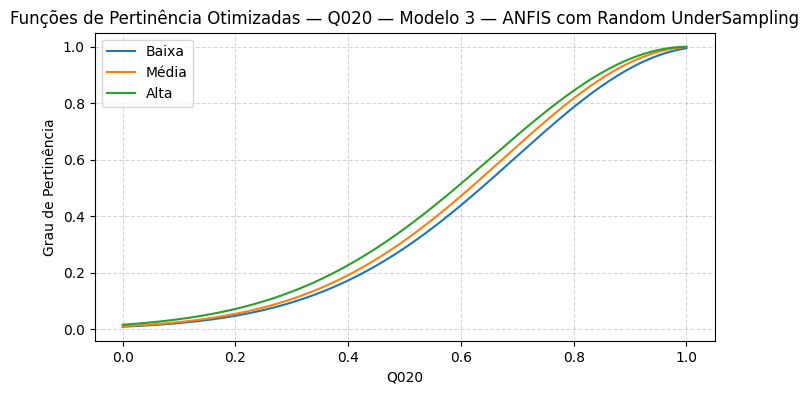

In [30]:
# ============================================================
# MODELO 3 — ANFIS CLASSIFICADOR COM RANDOM UNDERSAMPLING
# ============================================================

undersampler = RandomUnderSampler(random_state=42)

X_treino_under, y_treino_under = undersampler.fit_resample(
    X_treino_base,
    y_treino_base
)

print("\n" + "="*60)
print("BALANCEAMENTO — RANDOM UNDERSAMPLING")
print("="*60)

print("\nDistribuição das classes antes do balanceamento:")
print(pd.Series(y_treino_base).value_counts().sort_index())

print("\nDistribuição das classes após Random UnderSampling:")
print(pd.Series(y_treino_under).value_counts().sort_index())

print("\nDistribuição das classes no teste, sem balanceamento:")
print(pd.Series(y_teste).value_counts().sort_index())
print("="*60)

parametros_modelo3, resultado_modelo3 = treinar_anfis(
    nome_modelo='Modelo 3 — ANFIS com Random UnderSampling',
    X_treino_modelo=X_treino_under,
    y_treino_modelo=y_treino_under,
    X_teste=X_teste,
    y_teste=y_teste,
    maxiter=120,
    plotar_pertinencia=True
)

In [32]:
# ============================================================
# COMPARAÇÃO FINAL ENTRE OS MODELOS
# ============================================================

resultados_modelos = [
    resultado_modelo0,
    resultado_modelo1,
    resultado_modelo2,
    resultado_modelo3
]

df_resultados = pd.DataFrame(resultados_modelos)

print("\n" + "="*60)
print("COMPARAÇÃO FINAL ENTRE OS MODELOS")
print("="*60)

display(df_resultados)


COMPARAÇÃO FINAL ENTRE OS MODELOS


,modelo,acuracia,precision_macro,recall_macro,f1_macro,log_loss,acuracia_inicial,f1_macro_inicial
0,Modelo 0 — ANFIS sem Balanceamento,0.463762,0.478028,0.439143,0.438256,1.043669,0.461353,0.437603
1,Modelo 1 — ANFIS com Random OverSampling,0.451516,0.480500,0.442175,0.450704,1.055334,0.437663,0.436141
2,Modelo 2 — ANFIS com SMOTEN,0.452520,0.479336,0.441356,0.449605,1.055051,0.437663,0.436141
3,Modelo 3 — ANFIS com Random UnderSampling,0.452921,0.479943,0.443094,0.451453,1.054752,0.437663,0.436141


In [35]:
# ============================================================
# VALIDAÇÃO EXTERNA — DADOS COLETADOS DE FORMA ANÔNIMA EM UM CURSINHO
# ============================================================

# Os dados abaixo representam alunos de um cursinho, coletados de forma anônima.
# A validação externa usa as mesmas variáveis de entrada do modelo:
# melhores_colunas = ['TP_DEPENDENCIA_ADM_ESC', 'Q002', 'Q020']

dados_cursinho = pd.DataFrame({
    'Aluno': range(1, 12),

    'TP_DEPENDENCIA_ADM_ESC': [
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2
    ],

    'Q002': [
        4, 1, 5, 3, 4, 4, 4, 5, 4, 1, 4
    ],

    'Q020': [
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
    ],

    'Nota_Real': [
        720, 600, 760, 700, 840, 720, 840, 880, 840, 600, 820
    ]
})

#_______________ PREPARAÇÃO DOS DADOS DO CURSINHO _______________

X_cursinho = dados_cursinho[melhores_colunas].values.astype(float)

y_cursinho = dados_cursinho['Nota_Real'].apply(classificar_nota_redacao).values

dados_cursinho['Classe_Real'] = y_cursinho

dados_cursinho['Classe_Real_Nome'] = [
    nomes_classes[classe] for classe in y_cursinho
]

print("="*60)
print("VALIDAÇÃO EXTERNA — DADOS COLETADOS DE FORMA ANÔNIMA EM UM CURSINHO")
print("="*60)

print("\nDistribuição das classes reais no cursinho:")
print(dados_cursinho['Classe_Real_Nome'].value_counts())

display(dados_cursinho[[
    'Aluno',
    'TP_DEPENDENCIA_ADM_ESC',
    'Q002',
    'Q020',
    'Nota_Real',
    'Classe_Real_Nome'
]])

VALIDAÇÃO EXTERNA — DADOS COLETADOS DE FORMA ANÔNIMA EM UM CURSINHO

Distribuição das classes reais no cursinho:
Classe_Real_Nome
Média    6
Alta     5
Name: count, dtype: int64


,Aluno,TP_DEPENDENCIA_ADM_ESC,Q002,Q020,Nota_Real,Classe_Real_Nome
0,1,2,4,1,720,Média
1,2,2,1,1,600,Média
2,3,2,5,1,760,Média
3,4,2,3,1,700,Média
4,5,2,4,1,840,Alta
5,6,2,4,1,720,Média
6,7,2,4,1,840,Alta
7,8,2,5,1,880,Alta
8,9,2,4,1,840,Alta
9,10,2,1,1,600,Média


In [37]:
# ============================================================
# FUNÇÃO DE VALIDAÇÃO EXTERNA
# ============================================================

def validar_no_cursinho(nome_modelo, parametros_modelo):
    probabilidades = forward_anfis(parametros_modelo, X_cursinho)

    classes_preditas = np.argmax(probabilidades, axis=1)

    acuracia = accuracy_score(y_cursinho, classes_preditas)

    f1_macro_todas_classes = f1_score(
        y_cursinho,
        classes_preditas,
        labels=np.arange(num_classes),
        average='macro',
        zero_division=0
    )

    classes_presentes = np.unique(y_cursinho)

    f1_macro_classes_presentes = f1_score(
        y_cursinho,
        classes_preditas,
        labels=classes_presentes,
        average='macro',
        zero_division=0
    )

    resultado = {
        'modelo': nome_modelo,
        'acuracia_cursinho': acuracia,
        'f1_macro_todas_classes_cursinho': f1_macro_todas_classes,
        'f1_macro_classes_presentes_cursinho': f1_macro_classes_presentes
    }

    return resultado, classes_preditas

In [38]:
# ============================================================
# VALIDAÇÃO DOS MODELOS TREINADOS NO CONJUNTO DO CURSINHO
# ============================================================

modelos_treinados = {
    resultado_modelo0['modelo']: parametros_modelo0,
    resultado_modelo1['modelo']: parametros_modelo1,
    resultado_modelo2['modelo']: parametros_modelo2,
    resultado_modelo3['modelo']: parametros_modelo3
}

resultados_cursinho = []
predicoes_cursinho = {}

for nome_modelo, parametros_modelo in modelos_treinados.items():
    resultado, classes_preditas = validar_no_cursinho(
        nome_modelo,
        parametros_modelo
    )

    resultados_cursinho.append(resultado)

    predicoes_cursinho[nome_modelo] = classes_preditas


df_resultados_cursinho = pd.DataFrame(resultados_cursinho)

print("="*60)
print("RESULTADOS DA VALIDAÇÃO EXTERNA NO CURSINHO")
print("="*60)

display(df_resultados_cursinho)

RESULTADOS DA VALIDAÇÃO EXTERNA NO CURSINHO


,modelo,acuracia_cursinho,f1_macro_todas_classes_cursinho,f1_macro_classes_presentes_cursinho
0,Modelo 0 — ANFIS sem Balanceamento,0.363636,0.177778,0.266667
1,Modelo 1 — ANFIS com Random OverSampling,0.272727,0.142857,0.214286
2,Modelo 2 — ANFIS com SMOTEN,0.272727,0.142857,0.214286
3,Modelo 3 — ANFIS com Random UnderSampling,0.272727,0.142857,0.214286


In [39]:
# ============================================================
# COMPARAÇÃO — TESTE INEP x VALIDAÇÃO EXTERNA NO CURSINHO
# ============================================================

df_comparacao_inep_cursinho = df_resultados.merge(
    df_resultados_cursinho,
    on='modelo',
    how='inner'
)

colunas_comparacao = [
    'modelo',
    'acuracia',
    'f1_macro',
    'acuracia_cursinho',
    'f1_macro_todas_classes_cursinho',
    'f1_macro_classes_presentes_cursinho'
]

df_comparacao_inep_cursinho = df_comparacao_inep_cursinho[colunas_comparacao]

df_comparacao_inep_cursinho = df_comparacao_inep_cursinho.rename(columns={
    'acuracia': 'acuracia_teste_inep',
    'f1_macro': 'f1_macro_teste_inep'
})

print("="*70)
print("COMPARAÇÃO ENTRE TESTE INEP E VALIDAÇÃO EXTERNA")
print("="*70)

display(df_comparacao_inep_cursinho)

COMPARAÇÃO ENTRE TESTE INEP E VALIDAÇÃO EXTERNA


,modelo,acuracia_teste_inep,f1_macro_teste_inep,acuracia_cursinho,f1_macro_todas_classes_cursinho,f1_macro_classes_presentes_cursinho
0,Modelo 0 — ANFIS sem Balanceamento,0.463762,0.438256,0.363636,0.177778,0.266667
1,Modelo 1 — ANFIS com Random OverSampling,0.451516,0.450704,0.272727,0.142857,0.214286
2,Modelo 2 — ANFIS com SMOTEN,0.452520,0.449605,0.272727,0.142857,0.214286
3,Modelo 3 — ANFIS com Random UnderSampling,0.452921,0.451453,0.272727,0.142857,0.214286


<Figure size 1000x500 with 0 Axes>

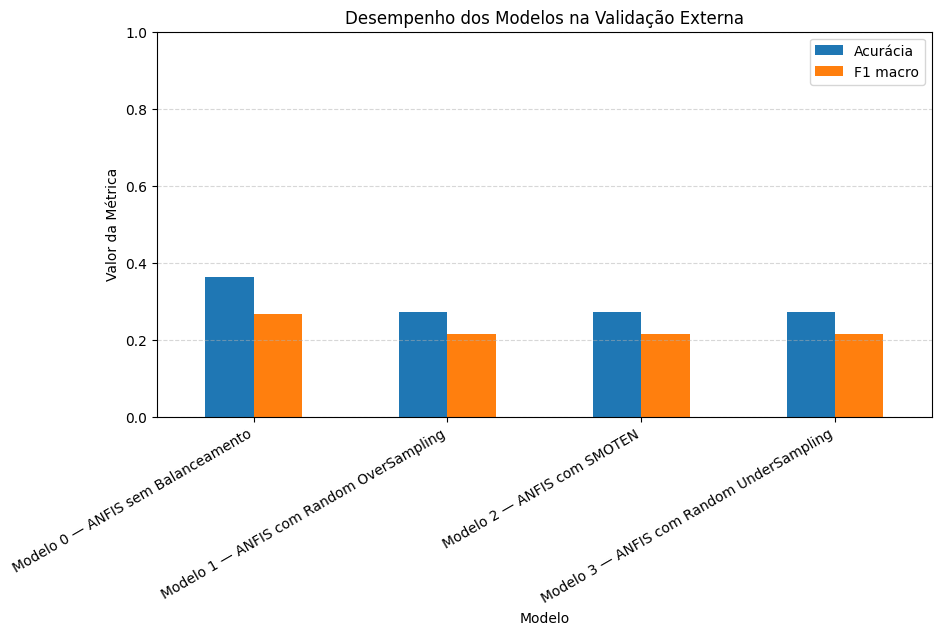

In [40]:
# ============================================================
# GRÁFICO 1 — ACURÁCIA E F1-SCORE NO CURSINHO
# ============================================================

df_plot_cursinho = df_resultados_cursinho.copy()

df_plot_cursinho = df_plot_cursinho.set_index('modelo')[
    [
        'acuracia_cursinho',
        'f1_macro_classes_presentes_cursinho'
    ]
]

plt.figure(figsize=(10, 5))

df_plot_cursinho.plot(kind='bar', figsize=(10, 5))

plt.title('Desempenho dos Modelos na Validação Externa')
plt.ylabel('Valor da Métrica')
plt.xlabel('Modelo')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Acurácia', 'F1 macro'])
plt.show()

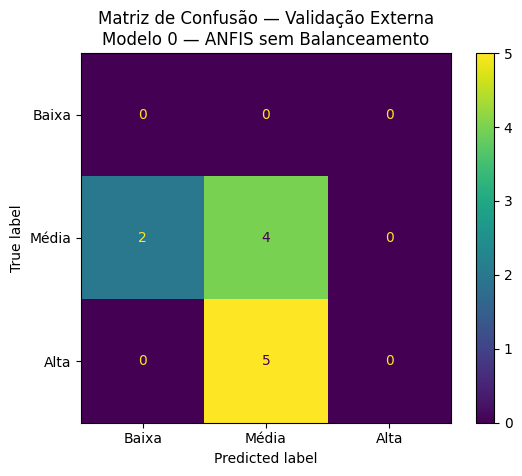

In [41]:
# ============================================================
# GRÁFICO 2 — MATRIZ DE CONFUSÃO DO MELHOR MODELO NO CURSINHO
# ============================================================

melhor_linha_cursinho = df_resultados_cursinho.sort_values(
    by='f1_macro_classes_presentes_cursinho',
    ascending=False
).iloc[0]

melhor_modelo_cursinho = melhor_linha_cursinho['modelo']

classes_preditas_melhor_modelo = predicoes_cursinho[melhor_modelo_cursinho]

matriz_confusao_cursinho = confusion_matrix(
    y_cursinho,
    classes_preditas_melhor_modelo,
    labels=np.arange(num_classes)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_cursinho,
    display_labels=nomes_classes
)

disp.plot()

plt.title(f'Matriz de Confusão — Validação Externa\n{melhor_modelo_cursinho}')
plt.show()

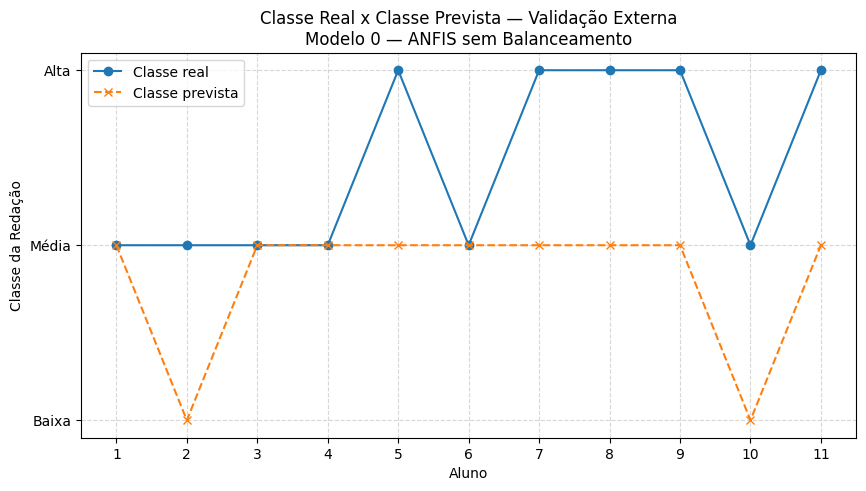

In [42]:
# ============================================================
# GRÁFICO 3 — CLASSE REAL x CLASSE PREVISTA POR ALUNO
# ============================================================

alunos = dados_cursinho['Aluno'].values

plt.figure(figsize=(10, 5))

plt.plot(
    alunos,
    y_cursinho,
    marker='o',
    label='Classe real'
)

plt.plot(
    alunos,
    classes_preditas_melhor_modelo,
    marker='x',
    linestyle='--',
    label='Classe prevista'
)

plt.yticks(
    ticks=np.arange(num_classes),
    labels=nomes_classes
)

plt.title(f'Classe Real x Classe Prevista — Validação Externa\n{melhor_modelo_cursinho}')
plt.xlabel('Aluno')
plt.ylabel('Classe da Redação')
plt.xticks(alunos)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()